In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import emoji
from pyvi import ViTokenizer

# Cài đặt hiển thị đồ thị
%matplotlib inline
sns.set_theme(style="whitegrid")

In [16]:
# Tải dữ liệu
df = pd.read_csv('movie_reviews.csv')

# Xem 5 dòng đầu tiên
display(df.head())

# Xóa các dòng không có comment
df = df.dropna(subset=['comment'])

,rating,comment,Movie_Title,Movie_URL
0,10,Thật sự mình thích cái cách Trấn Thành đem thể...,Thỏ Ơi!!,https://www.momo.vn/cinema/tho-oi-24729/review
1,10,Thỏ Ơi là một làn gió mới đầy trẻ trung với đi...,Thỏ Ơi!!,https://www.momo.vn/cinema/tho-oi-24729/review
2,10,Lời khuyên cho mấy cặp đôi đang yêu nhau thì k...,Thỏ Ơi!!,https://www.momo.vn/cinema/tho-oi-24729/review
3,10,"Phim của Trấn Thành công nhận là có hơi “chợ”,...",Thỏ Ơi!!,https://www.momo.vn/cinema/tho-oi-24729/review
4,9,Dạo này mình hay quên trước quên sau nên đi co...,Thỏ Ơi!!,https://www.momo.vn/cinema/tho-oi-24729/review


C:\Users\admin\AppData\Local\Temp\ipykernel_7928\449394091.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='rating', palette='viridis')


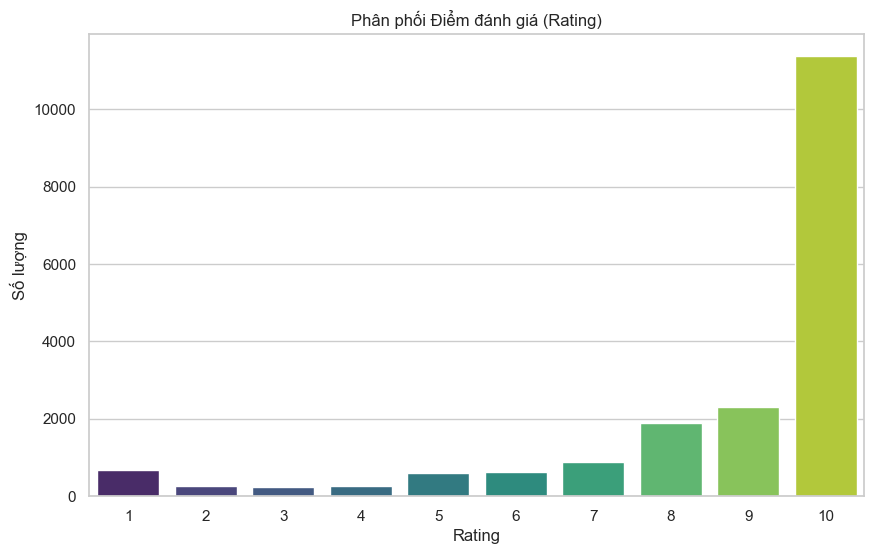

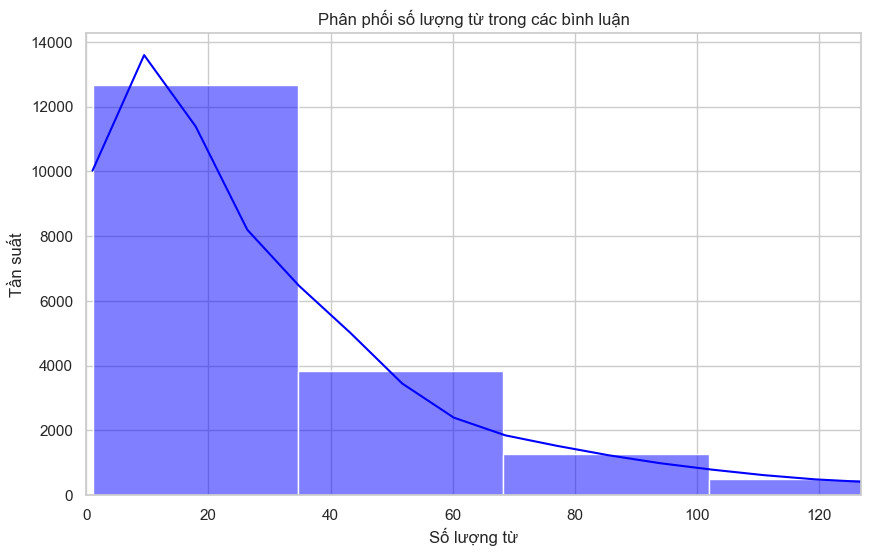

C:\Users\admin\AppData\Local\Temp\ipykernel_7928\449394091.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_movies.index, x=top_movies.values, palette='magma')


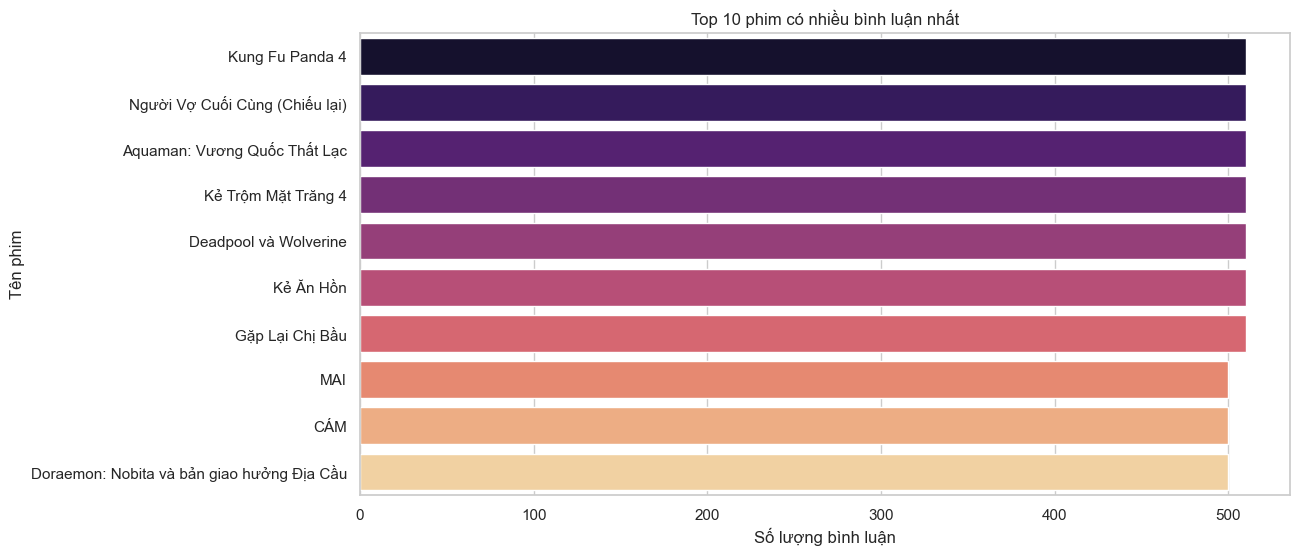

In [17]:
# 1. Biểu đồ phân phối Rating (Điểm đánh giá)
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='rating', palette='viridis')
plt.title('Phân phối Điểm đánh giá (Rating)')
plt.xlabel('Rating')
plt.ylabel('Số lượng')
plt.show()

# 2. Thống kê chiều dài của Comment (số lượng từ)
df['word_count'] = df['comment'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 6))
sns.histplot(df['word_count'], bins=50, kde=True, color='blue')
plt.title('Phân phối số lượng từ trong các bình luận')
plt.xlabel('Số lượng từ')
plt.ylabel('Tần suất')
plt.xlim(0, df['word_count'].quantile(0.95)) # Cắt đuôi để biểu đồ dễ nhìn hơn (hiển thị 95% dữ liệu)
plt.show()

# 3. Top 10 phim có nhiều đánh giá nhất
plt.figure(figsize=(12, 6))
top_movies = df['Movie_Title'].value_counts().head(10)
sns.barplot(y=top_movies.index, x=top_movies.values, palette='magma')
plt.title('Top 10 phim có nhiều bình luận nhất')
plt.xlabel('Số lượng bình luận')
plt.ylabel('Tên phim')
plt.show()

In [22]:
import requests
import re
import emoji
from pyvi import ViTokenizer

# 1. TẢI DANH SÁCH STOPWORD TIẾNG VIỆT
url = "https://raw.githubusercontent.com/stopwords/vietnamese-stopwords/master/vietnamese-stopwords.txt"

# Thay thế khoảng trắng bằng dấu gạch dưới để khớp với format của ViTokenizer
vietnamese_stopwords = set([line.strip().replace(" ", "_") for line in response.text.split('\n') if line])
important_sentiment_words = {
        "hay", "quá", "tốt", "đỉnh", "tuyệt", "tuyệt_vời", "xuất_sắc", "ổn", 
        "dở", "tệ", "chê", "chán", "buồn", "vui", "thích", "ghét", "sợ",
        "không", "chưa", "chẳng", "đẹp", "mới", "cảm_động", "hấp_dẫn"
    }
    
# Xóa các từ quan trọng này khỏi tập Stopword (nếu có) để không bị lọc mất
vietnamese_stopwords = vietnamese_stopwords - important_sentiment_words   

# Danh sách tất cả các nguyên âm tiếng Việt (Dùng để kiểm tra từ rác/spam)
VOWELS = r'[aeiouyáàảãạâấầẩẫậăắằẳẵặéèẻẽẹêếềểễệíìỉĩịóòỏõọôốồổỗộơớờởỡợúùủũụưứừửữựýỳỷỹỵ]'

# 2. HÀM LÀM SẠCH VÀ TIỀN XỬ LÝ (PREPROCESSING)
def clean_vietnamese_text_final(text):
    if not isinstance(text, str):
        return ""
    
    # Bước 1: Chữ thường, xóa Emoji và URL
    text = text.lower()
    text = emoji.replace_emoji(text, replace='')
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'[^\w\s\u00C0-\u1EF9]', ' ', text)

    # Bước 2: Xóa lỗi chữ "thu gọn" (kể cả khi bị dính liền vào chữ trước đó do lỗi crawl)
    text = text.replace('thu gọn', '')
    
    # Bước 3: Sửa lỗi gõ lặp nguyên âm có dấu (VD: quáaaaa -> quá, thôiííí -> thôi)
    text = re.sub(r'(á|à|ả|ã|ạ|â|ấ|ầ|ẩ|ẫ|ậ|ă|ắ|ằ|ẳ|ẵ|ặ)a+', r'\1', text)
    text = re.sub(r'(ó|ò|ỏ|õ|ọ|ô|ố|ồ|ổ|ỗ|ộ|ơ|ớ|ờ|ở|ỡ|ợ)o+', r'\1', text)
    text = re.sub(r'(é|è|ẻ|ẽ|ẹ|ê|ế|ề|ể|ễ|ệ)e+', r'\1', text)
    text = re.sub(r'(í|ì|ỉ|ĩ|ị)i+', r'\1', text)
    text = re.sub(r'(ú|ù|ủ|ũ|ụ|ư|ứ|ừ|ử|ữ|ự)u+', r'\1', text)
    text = re.sub(r'(ý|ỳ|ỷ|ỹ|ỵ)y+', r'\1', text)
    
    # Bước 4: Thu gọn các chữ cái lặp lại từ 2 lần trở lên (VD: hayyyyy -> hay, xemmm -> xem)
    text = re.sub(r'([a-z\u00C0-\u1EF9])\1+', r'\1', text)
    
    # Bước 5: Xóa ký tự đặc biệt, dấu câu (chỉ giữ lại chữ, số và khoảng trắng)
    text = re.sub(r'[^\w\s\u00C0-\u1EF9]', ' ', text)
    
    # Bước 6: Lọc từ rác/spam (Gibberish filter)
    words = text.split()
    valid_words = []
    for word in words:
        # Bỏ qua từ quá dài (âm tiết tiếng Việt thường không vượt quá 7-8 ký tự)
        if len(word) > 10:
            continue
        # Bỏ qua từ KHÔNG chứa bất kỳ nguyên âm nào (VD: "kkk", "hmmm", "jksbs")
        if not re.search(VOWELS, word):
            continue
        valid_words.append(word)
        
    filtered_text = ' '.join(valid_words)
    
    # Bước 7: Tokenize (Tách từ ghép tiếng Việt bằng dấu '_')
    tokenized_text = ViTokenizer.tokenize(filtered_text)
    
    # Bước 8: Xóa Stopword và các khoảng trắng thừa
    final_words = tokenized_text.split()
    clean_words = [w for w in final_words if w not in vietnamese_stopwords]
    
    return ' '.join(clean_words)

In [23]:
# 1. Áp dụng hàm làm sạch tổng hợp
df['clean_comment'] = df['comment'].apply(clean_vietnamese_text_final)

# 2. Xóa bỏ các comment bị rỗng hoặc quá ngắn (< 2 từ) sau khi đã làm sạch
df_clean = df[df['clean_comment'].str.strip() != '']
df_clean = df_clean[df_clean['clean_comment'].str.split().str.len() >= 2]

# 3. Lọc lấy các cột cần thiết
final_df = df_clean[['rating', 'clean_comment', 'Movie_Title']]

# 4. Hiển thị 10 kết quả đầu tiên để kiểm tra
display(final_df.head(10))

# 5. Lưu kết quả ra file CSV chuẩn
output_filename = 'movie_reviews_cleaned.csv'
final_df.to_csv(output_filename, index=False, encoding='utf-8-sig')

,rating,clean_comment,Movie_Title
0,10,thích trấn thành đem thể_loại thriler màn_ảnh ...,Thỏ Ơi!!
1,10,thỏ làn gió mới trẻ_trung rực_rỡ nằm hình_ảnh ...,Thỏ Ơi!!
2,10,khuyên mấy cặp đôi yêu không đi thỏ chột_dạ lắ...,Thỏ Ơi!!
3,10,phim trấn thành_công_nhận hơi chợ ko phim chợ ...,Thỏ Ơi!!
4,9,dạo hay quên quên đi coi film quên review film...,Thỏ Ơi!!
5,9,trấn thành dàn cast đỉnh quá diễn tròn vai sợ ...,Thỏ Ơi!!
6,10,phim thỏ mới rời đi có_lí_do sống câu không đá...,Thỏ Ơi!!
7,10,phim hay cảm_động tình_yêu diễn_viên phim đa_p...,Thỏ Ơi!!
8,10,chê chê phim nhàm hay dàn diễn_viên diễn chưa ...,Thỏ Ơi!!
9,10,tinh_hoa hội_tụ phim kịch_bản hay đạo_diễn_xuấ...,Thỏ Ơi!!
